
Original Shape: (3500, 1500)
Model Input: (3500, 1500, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1500, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 1500, 64)          │             256 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 1500, 64)          │             512 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 1500, 64)          │             768 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1500, 192)         │               0 │ conv1d[0][0],              │
│                               │                           │                 │ conv1d_1[0][0],            │
│                               │                           │                 │ conv1d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 1500, 192)         │             768 │ concatenate[0][0]          │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 750, 192)          │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 750, 256)          │         247,296 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 750, 1)            │             257 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ softmax (Softmax)             │ (None, 750, 1)            │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 750, 256)          │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ softmax[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 256)               │               0 │ multiply[0][0]             │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          65,792 │ global_average_pooling1d[… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 315,649 (1.20 MB)

 Trainable params: 315,265 (1.20 MB)

 Non-trainable params: 384 (1.50 KB)

110/110 ━━━━━━━━━━━━━━━━━━━━ 88s 645ms/step

Feature Shape: (3500, 256)

Saved
ecg_features2.npy

NaN Count: 0

Min: 0.0
Max: 0.0010916146
Mean: 2.744836e-05
STD: 4.314819e-05


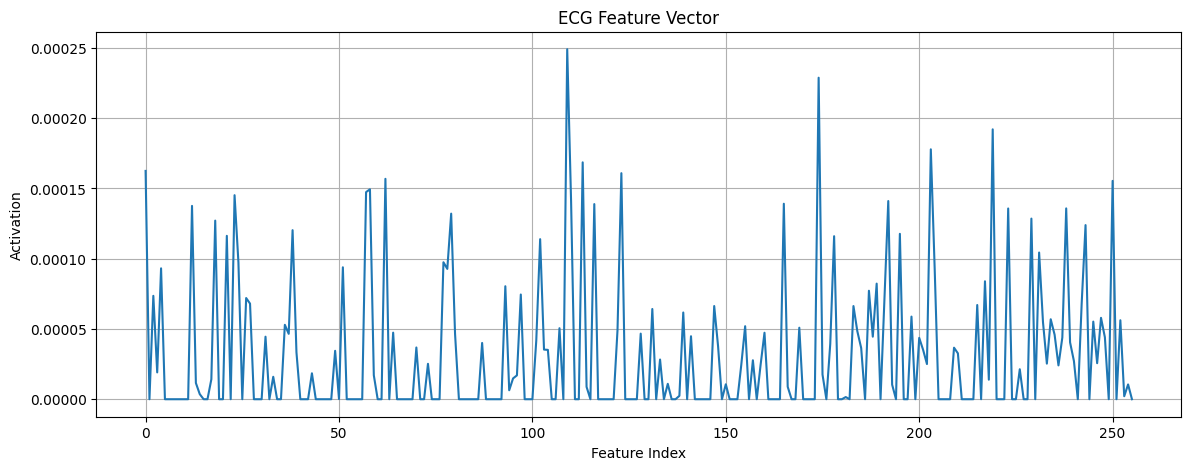

In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt


# =====================================
# FIX RANDOMNESS
# =====================================

tf.random.set_seed(42)

np.random.seed(42)


# =====================================
# LOAD
# =====================================

X=np.load(
"ecg_segments2.npy"
)

print(
"\nOriginal Shape:",
X.shape
)

X=X[...,None]

print(
"Model Input:",
X.shape
)


# =====================================
# ATTENTION
# =====================================

def attention(x):

    score=Dense(

        1,

        activation="tanh"

    )(x)

    weight=Softmax(

        axis=1

    )(score)

    x=Multiply()(

        [

            x,

            weight

        ]

    )

    return x


# =====================================
# MODEL
# =====================================

inp=Input(

(

1500,

1

)

)


# MULTISCALE

k1=Conv1D(

64,

3,

padding="same",

activation="relu"

)(inp)


k2=Conv1D(

64,

7,

padding="same",

activation="relu"

)(inp)


k3=Conv1D(

64,

11,

padding="same",

activation="relu"

)(inp)


x=Concatenate()(

[

k1,

k2,

k3

]

)


x=BatchNormalization()(x)

x=MaxPool1D(

2

)(x)


# BIGRU

x=Bidirectional(

GRU(

128,

return_sequences=True

)

)(x)


# ATTENTION

x=attention(

x

)


# FEATURE

x=GlobalAveragePooling1D()(x)


feat=Dense(

256,

activation="relu"

)(x)


model=Model(

inp,

feat

)


model.summary()


# =====================================
# FEATURE EXTRACTION
# =====================================

ecg_features=model.predict(

X,

batch_size=32,

verbose=1

)


print(

"\nFeature Shape:",

ecg_features.shape

)


# =====================================
# SAVE
# =====================================

np.save(

"ecg_features2.npy",

ecg_features

)


print(

"\nSaved"

)

print(

"ecg_features2.npy"

)


# =====================================
# CHECK
# =====================================

print(

"\nNaN Count:",

np.isnan(

ecg_features

).sum()

)


print(

"\nMin:",

np.min(

ecg_features

)

)

print(

"Max:",

np.max(

ecg_features

)

)

print(

"Mean:",

np.mean(

ecg_features

)

)

print(

"STD:",

np.std(

ecg_features

)

)


# =====================================
# VISUAL
# =====================================

plt.figure(

figsize=(14,5)

)

plt.plot(

ecg_features[0]

)

plt.title(

"ECG Feature Vector"

)

plt.xlabel(

"Feature Index"

)

plt.ylabel(

"Activation"

)

plt.grid()

plt.show()